In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset/Advertising.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns)

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Shape: (200, 5)

Columns: Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


In [3]:
# Remove the unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Check dataset information
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Descriptive Statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


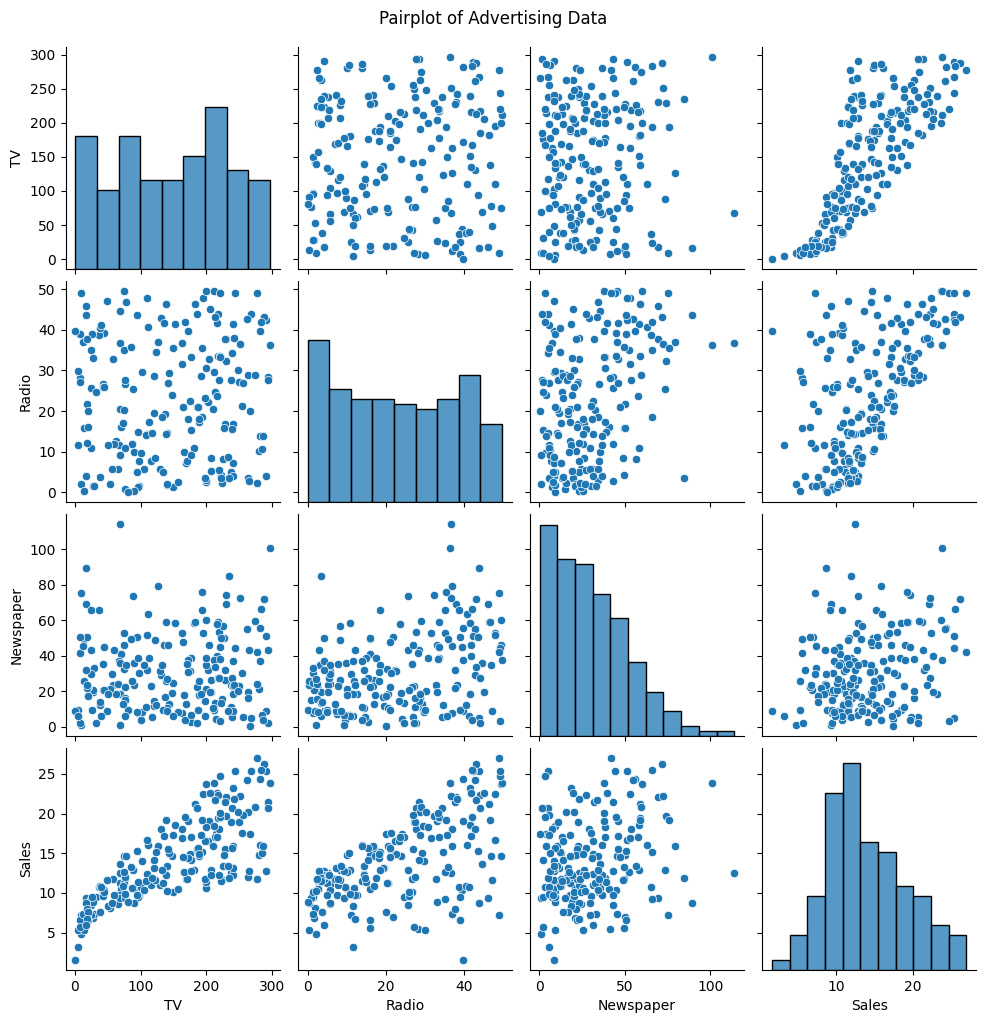

In [4]:
# Pairplot to visualize relationships between all variables

sns.pairplot(df)

plt.suptitle("Pairplot of Advertising Data", y=1.02)
plt.show()

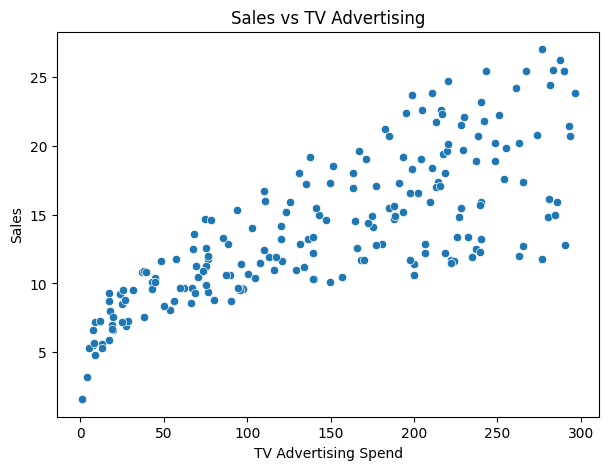

In [5]:
# Sales vs TV Advertising

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="TV", y="Sales")

plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.show()


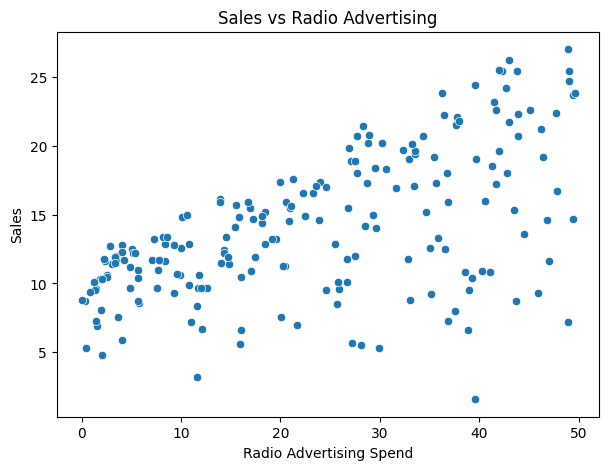

In [6]:
# Sales vs Radio Advertising

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Radio", y="Sales")

plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.show()

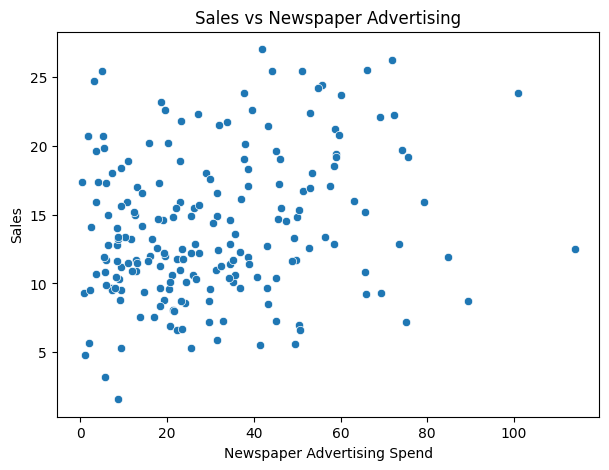

In [7]:
# Sales vs Newspaper Advertising

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Newspaper", y="Sales")

plt.title("Sales vs Newspaper Advertising")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.show()

In [8]:
# Correlation matrix

correlation = df.corr()

print(correlation)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.782224
Radio      0.054809  1.000000   0.354104  0.576223
Newspaper  0.056648  0.354104   1.000000  0.228299
Sales      0.782224  0.576223   0.228299  1.000000


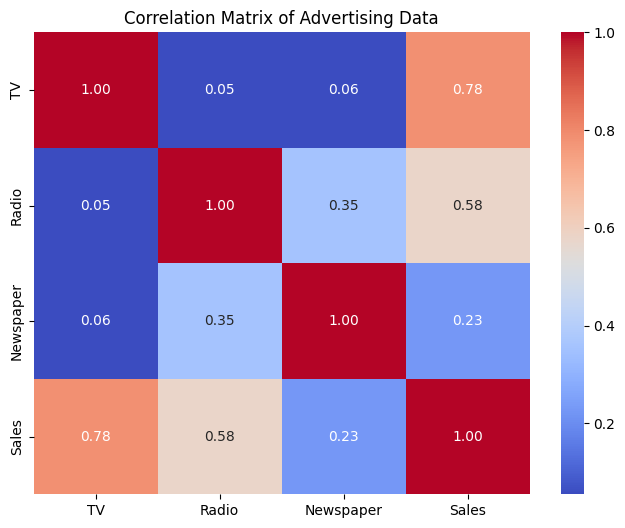

In [9]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Advertising Data")
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# Features
X = df[["TV", "Radio", "Newspaper"]]

# Target
y = df["Sales"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (160, 3)
Testing features: (40, 3)
Training target: (160,)
Testing target: (40,)


In [11]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [12]:
# Predict Sales using the trained Linear Regression model

y_pred_linear = linear_model.predict(X_test)

print("First 10 Actual Sales:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Sales:")
print(y_pred_linear[:10])

First 10 Actual Sales:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9]

First 10 Predicted Sales:
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Performance
--------------------------------
MAE : 1.4607567168117603
RMSE: 1.78159966153345
R²  : 0.899438024100912


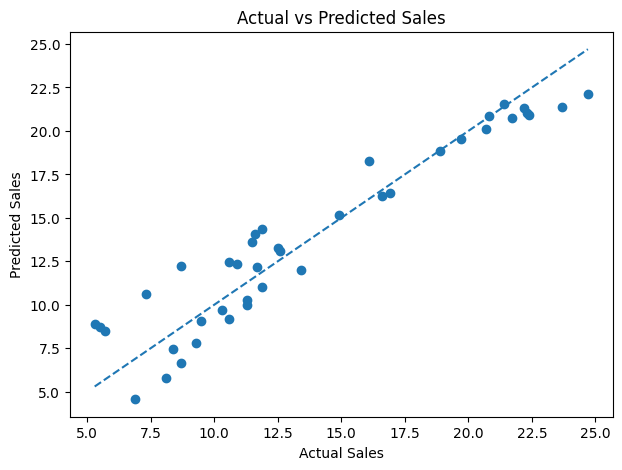

In [15]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_linear)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

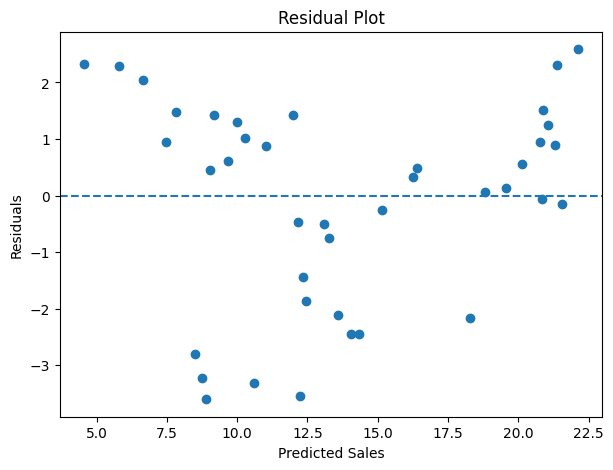

In [16]:
residuals = y_test - y_pred_linear

plt.figure(figsize=(7, 5))

plt.scatter(y_pred_linear, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [17]:
import joblib

joblib.dump(linear_model, "sales_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [18]:
loaded_model = joblib.load("sales_prediction_model.pkl")

sample_prediction = loaded_model.predict([[200, 30, 20]])

print("Predicted Sales:", sample_prediction[0])

Predicted Sales: 17.656044745724536


C:\Users\kavij\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [19]:
sample = pd.DataFrame({
    "TV": [200],
    "Radio": [30],
    "Newspaper": [20]
})

sample_prediction = loaded_model.predict(sample)

print("Predicted Sales:", sample_prediction[0])

Predicted Sales: 17.656044745724536
